# Assignment 1: Training models
## OLS Regression with visual diagnostics

This notebook fits a simple ordinary least squares (OLS) regression model for advertising budget and sales, then uses several views to understand the relationship, fit quality, residual behavior, and prediction uncertainty.

The project environment provides the plotting stack through `uv`: NumPy, pandas, Matplotlib, Seaborn, and statsmodels.

## Analysis map

1. Load and validate the ten observations.
2. Explore the data with tables and overview plots.
3. Calculate OLS coefficients manually, then cross-check them with statsmodels.
4. Visualize the fitted line, confidence band, prediction interval, and USD 12,000 forecast.
5. Inspect residuals, normality, leverage, correlation, and explained variation.
6. Summarize the assignment answers and modeling limitations.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
from IPython.display import display
from scipy import stats

class DualFormatTable:
    """Render a DataFrame as HTML in notebooks and LaTeX in PDF exports."""

    def __init__(self, frame: pd.DataFrame) -> None:
        self.frame = frame

    def _repr_html_(self) -> str:
        return self.frame.to_html(index=False)

    def _repr_latex_(self) -> str:
        return self.frame.to_latex(index=False, escape=True)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update(
    {
        "figure.dpi": 110,
        "axes.titleweight": "bold",
        "axes.labelweight": "bold",
        "figure.constrained_layout.use": True,
    }
)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")

## Problem setup

- **Advertising Budget (X):** amount spent on advertising, measured in thousands of dollars.
- **Sales (Y):** units sold, measured in thousands of units.

The simple linear model is `y_hat = b0 + b1 * x`, where `b0` is the intercept and `b1` is the slope.

In [2]:
df = pd.DataFrame(
    {
        "month": np.arange(1, 11),
        "advertising_budget": [3.0, 5.0, 2.0, 7.0, 8.0, 1.0, 4.0, 6.0, 9.0, 10.0],
        "sales": [6.0, 9.0, 4.0, 10.0, 12.0, 3.0, 7.0, 8.0, 13.0, 15.0],
    }
)

# Validate the raw data before calculating any model quantities.
assert df.shape == (10, 3)
assert df["month"].is_unique
assert not df.isna().any().any()
assert (df[["advertising_budget", "sales"]] >= 0).all().all()

display(DualFormatTable(df.round({"advertising_budget": 1, "sales": 1})))

month,advertising_budget,sales
1,3.0000,6.0000
2,5.0000,9.0000
3,2.0000,4.0000
4,7.0000,10.0000
5,8.0000,12.0000
6,1.0000,3.0000
7,4.0000,7.0000
8,6.0000,8.0000
9,9.0000,13.0000
10,10.0000,15.0000


## Descriptive statistics

The summary gives scale and spread before modeling. This prevents the regression coefficients from being interpreted without knowing the data range.

In [3]:
summary = (
    df[["advertising_budget", "sales"]]
    .describe()
    .T.rename(columns={"mean": "mean", "std": "std_dev"})[
        ["count", "mean", "std_dev", "min", "25%", "50%", "75%", "max"]
    ]
)
display(summary)
print(f"Pearson correlation: {df['advertising_budget'].corr(df['sales']):.6f}")

,count,mean,std_dev,min,25%,50%,75%,max
advertising_budget,10.0000,5.5000,3.0277,1.0000,3.2500,5.5000,7.7500,10.0000
sales,10.0000,8.7000,3.8887,3.0000,6.2500,8.5000,11.5000,15.0000


Pearson correlation: 0.986189


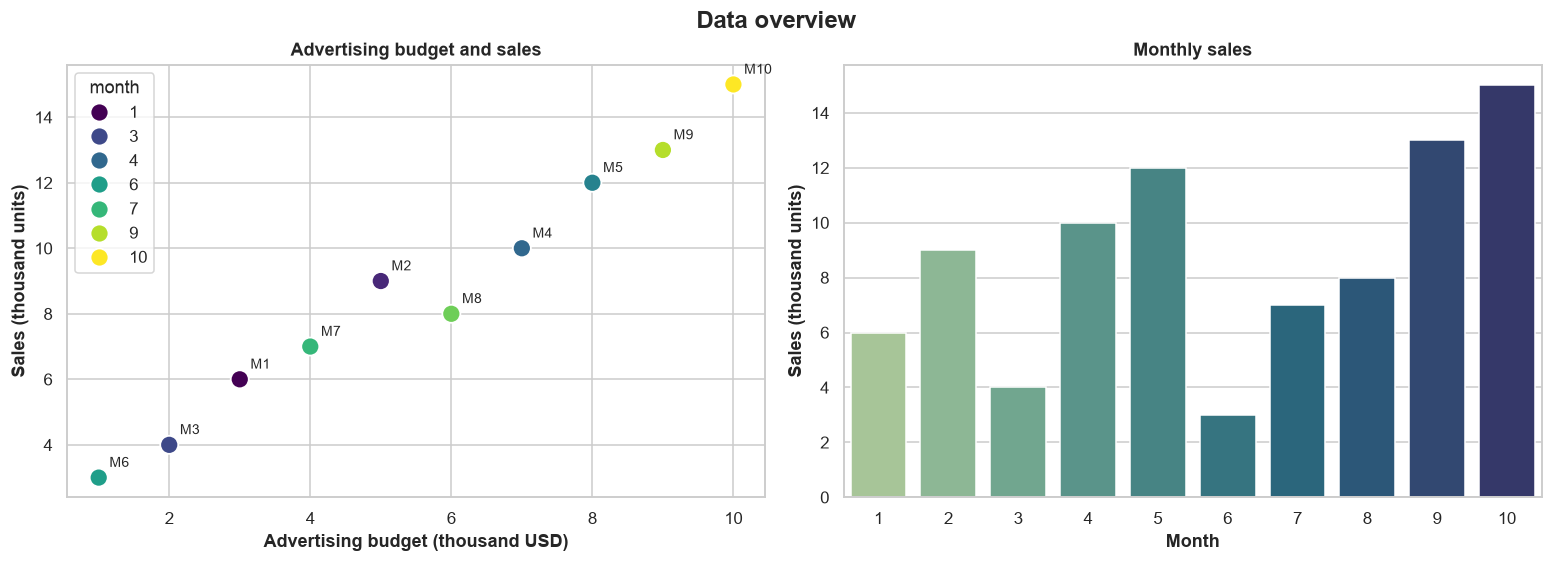

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(
    data=df,
    x="advertising_budget",
    y="sales",
    hue="month",
    palette="viridis",
    s=140,
    edgecolor="white",
    linewidth=1.2,
    ax=axes[0],
)
for _, row in df.iterrows():
    axes[0].annotate(
        f"M{int(row['month'])}",
        (row["advertising_budget"], row["sales"]),
        xytext=(7, 7),
        textcoords="offset points",
        fontsize=9,
    )
axes[0].set_title("Advertising budget and sales")
axes[0].set_xlabel("Advertising budget (thousand USD)")
axes[0].set_ylabel("Sales (thousand units)")

sns.barplot(
    data=df,
    x="month",
    y="sales",
    hue="month",
    palette="crest",
    legend=False,
    ax=axes[1],
)
axes[1].set_title("Monthly sales")
axes[1].set_xlabel("Month")
axes[1].set_ylabel("Sales (thousand units)")
fig.suptitle("Data overview", fontsize=16, fontweight="bold")
display(fig)
plt.close(fig)

### Reading the data overview

The scatter plot shows a strong positive relationship: higher advertising budgets generally match higher sales. The monthly bars show sales rising overall, with small month-to-month differences.

## OLS calculation

For simple linear regression, calculate the coefficients with:

- `b1 = Sxy / Sxx`
- `b0 = y_mean - b1 * x_mean`
- `Sxy = sum((x_i - x_mean) * (y_i - y_mean))`
- `Sxx = sum((x_i - x_mean) ** 2)`

The manual calculation is the primary implementation. `statsmodels` provides an independent cross-check and prediction intervals.

In [5]:
x = df["advertising_budget"].to_numpy(dtype=float)
y = df["sales"].to_numpy(dtype=float)
x_mean = x.mean()
y_mean = y.mean()
sxx = np.sum((x - x_mean) ** 2)
sxy = np.sum((x - x_mean) * (y - y_mean))
manual_slope = sxy / sxx
manual_intercept = y_mean - manual_slope * x_mean
manual_fitted = manual_intercept + manual_slope * x
manual_residuals = y - manual_fitted

print(f"x_mean = {x_mean:.6f}")
print(f"y_mean = {y_mean:.6f}")
print(f"Sxx = {sxx:.6f}")
print(f"Sxy = {sxy:.6f}")
print(f"Intercept (b0) = {manual_intercept:.6f}")
print(f"Slope (b1) = {manual_slope:.6f}")
print(f"Fitted line: y_hat = {manual_intercept:.4f} + {manual_slope:.4f}x")

assert np.isclose(manual_intercept, 1.7333333333)
assert np.isclose(manual_slope, 1.2666666667)

x_mean = 5.500000
y_mean = 8.700000
Sxx = 82.500000
Sxy = 104.500000
Intercept (b0) = 1.733333
Slope (b1) = 1.266667
Fitted line: y_hat = 1.7333 + 1.2667x


In [6]:
X = sm.add_constant(x, has_constant="add")
ols_results = sm.OLS(y, X).fit()

comparison = pd.DataFrame(
    {
        "manual OLS": [manual_intercept, manual_slope],
        "statsmodels OLS": ols_results.params,
    },
    index=["intercept", "slope"],
)
display(comparison)
print(f"Statsmodels R-squared: {ols_results.rsquared:.6f}")

assert np.allclose(ols_results.params, [manual_intercept, manual_slope])
assert np.isclose(ols_results.rsquared, 0.9725691893)

,manual OLS,statsmodels OLS
intercept,1.7333,1.7333
slope,1.2667,1.2667


Statsmodels R-squared: 0.972569


## Prediction at USD 12,000

The predictor is measured in thousands of dollars, so USD 12,000 corresponds to `x = 12.0`. The model's mean response interval and individual prediction interval show different uncertainty:

- **Confidence interval:** uncertainty around the mean sales response at a budget value.
- **Prediction interval:** uncertainty for one future observation, so it is wider.

In [7]:
prediction_budget_usd = 12_000
prediction_budget_thousands = prediction_budget_usd / 1_000
prediction_design = sm.add_constant(
    np.array([prediction_budget_thousands]),
    has_constant="add",
)
prediction_frame = ols_results.get_prediction(prediction_design).summary_frame(
    alpha=0.05
)
predicted_sales_thousands = float(prediction_frame["mean"].iloc[0])

prediction_table = pd.DataFrame(
    {
        "budget_usd": [prediction_budget_usd],
        "budget_thousands": [prediction_budget_thousands],
        "predicted_sales_thousands": [predicted_sales_thousands],
        "mean_ci_lower": [float(prediction_frame["mean_ci_lower"].iloc[0])],
        "mean_ci_upper": [float(prediction_frame["mean_ci_upper"].iloc[0])],
        "prediction_interval_lower": [float(prediction_frame["obs_ci_lower"].iloc[0])],
        "prediction_interval_upper": [float(prediction_frame["obs_ci_upper"].iloc[0])],
    }
)
display(prediction_table)
print(f"Predicted sales: {predicted_sales_thousands:.4f} thousand units")
print(f"Approximately {predicted_sales_thousands * 1_000:,.0f} units")

assert np.isclose(predicted_sales_thousands, 16.9333333333)

,budget_usd,budget_thousands,predicted_sales_thousands,mean_ci_lower,mean_ci_upper,prediction_interval_lower,prediction_interval_upper
0,12000,12.0000,16.9333,15.7008,18.1658,14.9332,18.9335


Predicted sales: 16.9333 thousand units
Approximately 16,933 units


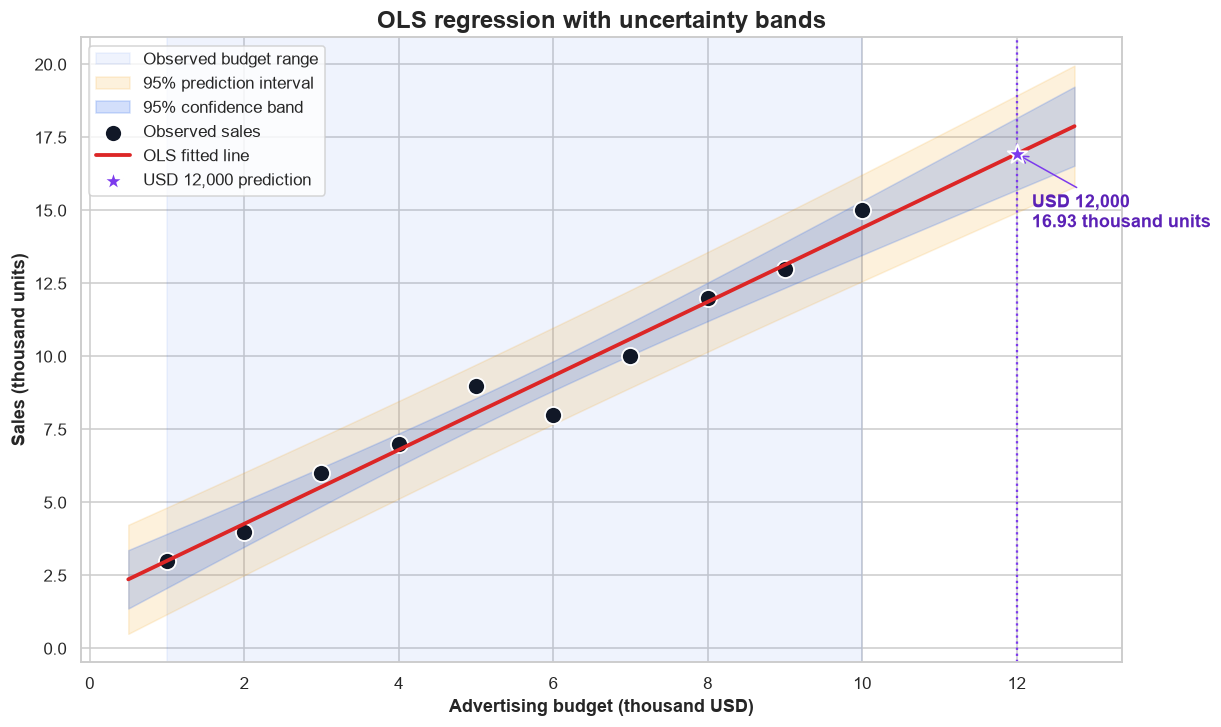

In [8]:
x_grid = np.linspace(x.min() - 0.5, 12.75, 250)
grid_design = sm.add_constant(x_grid, has_constant="add")
grid_frame = ols_results.get_prediction(grid_design).summary_frame(alpha=0.05)

fig, ax = plt.subplots(figsize=(11, 6.5))
ax.axvspan(
    x.min(),
    x.max(),
    color="#2563eb",
    alpha=0.07,
    label="Observed budget range",
)
ax.fill_between(
    x_grid,
    grid_frame["obs_ci_lower"].to_numpy(),
    grid_frame["obs_ci_upper"].to_numpy(),
    color="#f59e0b",
    alpha=0.14,
    label="95% prediction interval",
)
ax.fill_between(
    x_grid,
    grid_frame["mean_ci_lower"].to_numpy(),
    grid_frame["mean_ci_upper"].to_numpy(),
    color="#2563eb",
    alpha=0.20,
    label="95% confidence band",
)
sns.scatterplot(
    data=df,
    x="advertising_budget",
    y="sales",
    color="#111827",
    s=125,
    edgecolor="white",
    linewidth=1.2,
    label="Observed sales",
    ax=ax,
)
ax.plot(
    x_grid,
    grid_frame["mean"].to_numpy(),
    color="#dc2626",
    linewidth=2.5,
    label="OLS fitted line",
)
ax.scatter(
    [prediction_budget_thousands],
    [predicted_sales_thousands],
    color="#7c3aed",
    s=180,
    marker="*",
    edgecolor="white",
    linewidth=1.2,
    zorder=5,
    label="USD 12,000 prediction",
)
ax.axvline(prediction_budget_thousands, color="#7c3aed", linestyle=":", linewidth=1.5)
ax.annotate(
    f"USD 12,000\n{predicted_sales_thousands:.2f} thousand units",
    xy=(prediction_budget_thousands, predicted_sales_thousands),
    xytext=(10, -48),
    textcoords="offset points",
    arrowprops={"arrowstyle": "->", "color": "#7c3aed"},
    color="#5b21b6",
    fontweight="bold",
)
ax.set_title("OLS regression with uncertainty bands", fontsize=16)
ax.set_xlabel("Advertising budget (thousand USD)")
ax.set_ylabel("Sales (thousand units)")
ax.legend(loc="upper left", frameon=True)
display(fig)
plt.close(fig)

### Reading the regression plot

The black points are observed sales and the red line is the fitted OLS relationship. The blue confidence band describes uncertainty in the mean trend, while the wider orange band covers likely individual observations; the star is the USD 12,000 forecast.

### Coefficient interpretation

- **Slope:** each additional thousand dollars of advertising is associated with approximately 1.2667 thousand additional units sold.
- **Intercept:** the fitted model predicts approximately 1.7333 thousand units at zero advertising budget. Zero is outside the observed range, so this is an extrapolated baseline.
- **Prediction:** USD 12,000 gives approximately 16.9333 thousand units, or about 16,933 units. Since 12.0 is above the observed maximum of 10.0, this forecast is extrapolation.

In [9]:
influence = ols_results.get_influence()
diagnostics = df.assign(
    fitted=ols_results.fittedvalues,
    residual=ols_results.resid,
    studentized_residual=influence.resid_studentized_internal,
    leverage=influence.hat_matrix_diag,
    cooks_distance=influence.cooks_distance[0],
)

diagnostic_table = diagnostics[
    [
        "month",
        "sales",
        "fitted",
        "residual",
        "studentized_residual",
        "leverage",
        "cooks_distance",
    ]
].round(3)
display(DualFormatTable(diagnostic_table))
print(f"Residual mean: {diagnostics['residual'].mean():.6f}")
print(f"Residual standard deviation: {diagnostics['residual'].std(ddof=1):.6f}")

month,sales,fitted,residual,studentized_residual,leverage,cooks_distance
1,6.0000,5.5330,0.4670,0.7520,0.1760,0.0600
2,9.0000,8.0670,0.9330,1.4430,0.1030,0.1200
3,4.0000,4.2670,-0.2670,-0.4500,0.2480,0.0340
4,10.0000,10.6000,-0.6000,-0.9400,0.1270,0.0640
5,12.0000,11.8670,0.1330,0.2150,0.1760,0.0050
6,3.0000,3.0000,-0.0000,-0.0000,0.3450,0.0000
7,7.0000,6.8000,0.2000,0.3130,0.1270,0.0070
8,8.0000,9.3330,-1.3330,-2.0610,0.1030,0.2440
9,13.0000,13.1330,-0.1330,-0.2250,0.2480,0.0080
10,15.0000,14.4000,0.6000,1.0860,0.3450,0.3110


Residual mean: -0.000000
Residual standard deviation: 0.644061


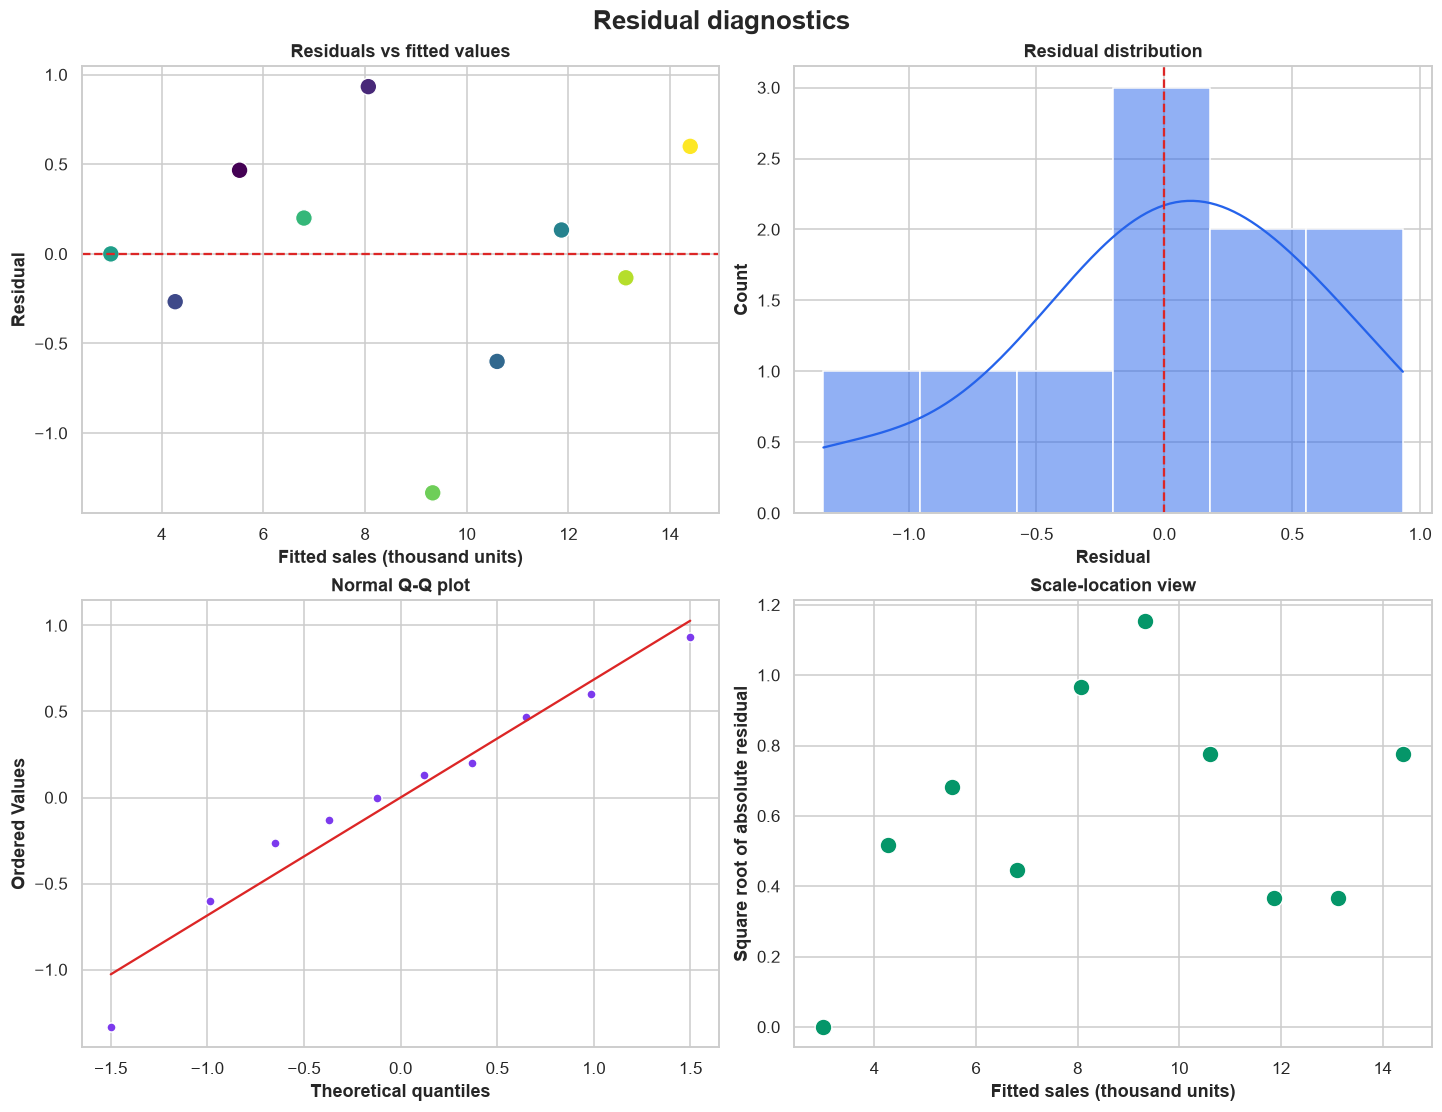

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(13, 10))

sns.scatterplot(
    data=diagnostics,
    x="fitted",
    y="residual",
    hue="month",
    palette="viridis",
    s=120,
    legend=False,
    ax=axes[0, 0],
)
axes[0, 0].axhline(0, color="#dc2626", linestyle="--", linewidth=1.5)
axes[0, 0].set_title("Residuals vs fitted values")
axes[0, 0].set_xlabel("Fitted sales (thousand units)")
axes[0, 0].set_ylabel("Residual")

sns.histplot(
    diagnostics["residual"],
    bins=6,
    kde=True,
    color="#2563eb",
    edgecolor="white",
    ax=axes[0, 1],
)
axes[0, 1].axvline(0, color="#dc2626", linestyle="--", linewidth=1.5)
axes[0, 1].set_title("Residual distribution")
axes[0, 1].set_xlabel("Residual")

stats.probplot(diagnostics["residual"], dist="norm", plot=axes[1, 0])
axes[1, 0].set_title("Normal Q-Q plot")
axes[1, 0].get_lines()[0].set_markerfacecolor("#7c3aed")
axes[1, 0].get_lines()[0].set_markeredgecolor("white")
axes[1, 0].get_lines()[1].set_color("#dc2626")

diagnostics["sqrt_abs_residual"] = np.sqrt(np.abs(diagnostics["residual"]))
sns.scatterplot(
    data=diagnostics,
    x="fitted",
    y="sqrt_abs_residual",
    color="#059669",
    s=120,
    ax=axes[1, 1],
)
axes[1, 1].set_title("Scale-location view")
axes[1, 1].set_xlabel("Fitted sales (thousand units)")
axes[1, 1].set_ylabel("Square root of absolute residual")

fig.suptitle("Residual diagnostics", fontsize=17, fontweight="bold")
display(fig)
plt.close(fig)

### Reading the residual plots

Residuals versus fitted values show no strong curve, and the histogram and Q-Q plot are roughly centered and reasonably close to a normal shape. The scale-location plot shows no obvious widening funnel. With only ten observations, these diagnostics are descriptive rather than decisive.

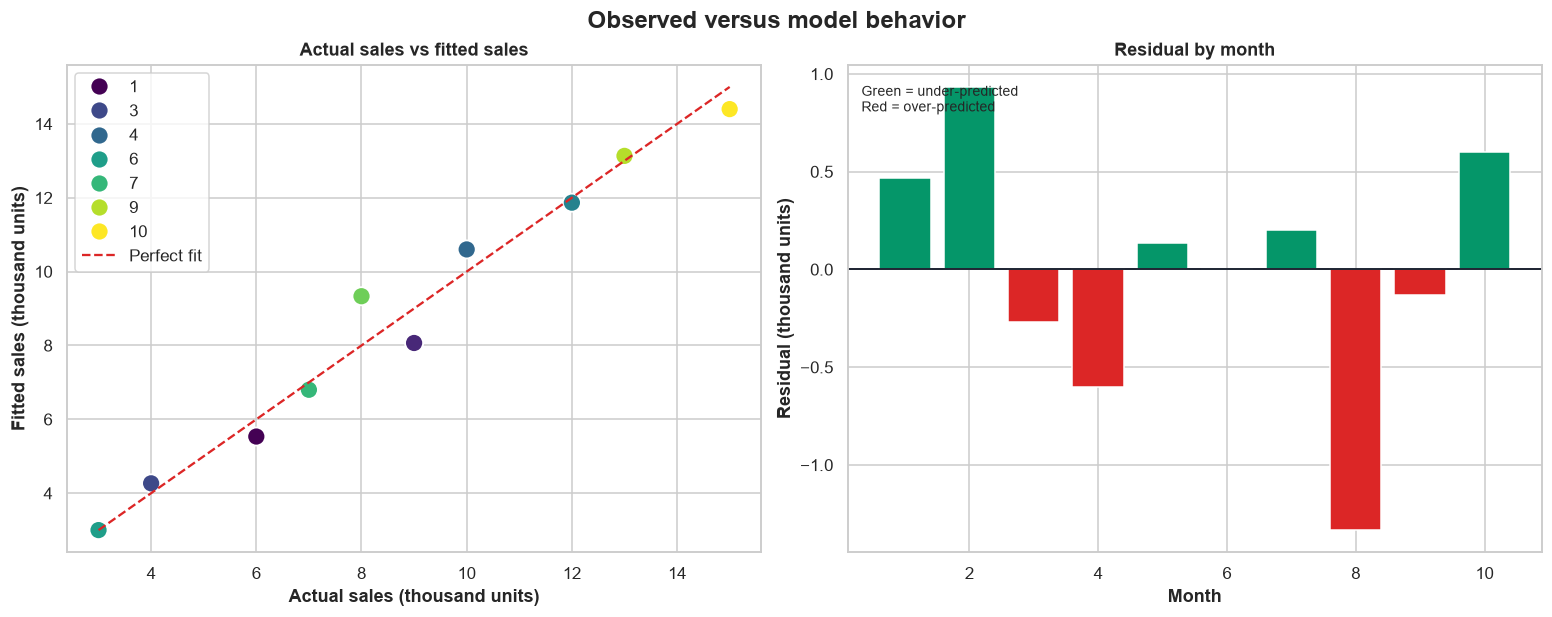

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

sns.scatterplot(
    data=diagnostics,
    x="sales",
    y="fitted",
    hue="month",
    palette="viridis",
    s=140,
    edgecolor="white",
    linewidth=1.2,
    ax=axes[0],
)
fit_limits = [
    min(diagnostics["sales"].min(), diagnostics["fitted"].min()),
    max(diagnostics["sales"].max(), diagnostics["fitted"].max()),
]
axes[0].plot(
    fit_limits, fit_limits, color="#dc2626", linestyle="--", label="Perfect fit"
)
axes[0].set_title("Actual sales vs fitted sales")
axes[0].set_xlabel("Actual sales (thousand units)")
axes[0].set_ylabel("Fitted sales (thousand units)")
axes[0].legend()

bar_colors = np.where(diagnostics["residual"] >= 0, "#059669", "#dc2626")
axes[1].bar(
    diagnostics["month"], diagnostics["residual"], color=bar_colors, edgecolor="white"
)
axes[1].axhline(0, color="#111827", linewidth=1.2)
axes[1].set_title("Residual by month")
axes[1].set_xlabel("Month")
axes[1].set_ylabel("Residual (thousand units)")
axes[1].text(
    0.02,
    0.96,
    "Green = under-predicted\nRed = over-predicted",
    transform=axes[1].transAxes,
    va="top",
    fontsize=9,
)

fig.suptitle("Observed versus model behavior", fontsize=16, fontweight="bold")
display(fig)
plt.close(fig)

### Reading observed versus fitted behavior

Points close to the diagonal show that fitted sales are close to actual sales. The residual bars show prediction direction by month: green means under-prediction and red means over-prediction.


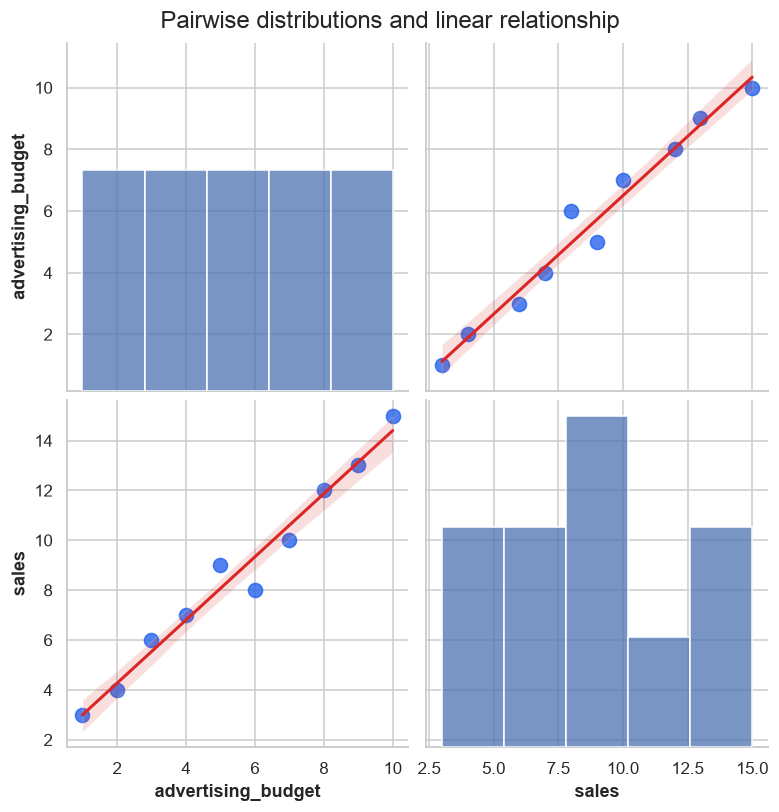

In [12]:
# Seaborn PairGrid uses tight_layout; disable constrained layout for this figure.
with plt.rc_context({"figure.constrained_layout.use": False}):
    pair_grid = sns.pairplot(
        df[["advertising_budget", "sales"]],
        kind="reg",
        diag_kind="hist",
        height=3.6,
        plot_kws={
            "scatter_kws": {"s": 85, "alpha": 0.8, "color": "#2563eb"},
            "line_kws": {"color": "#dc2626", "linewidth": 2},
        },
    )
pair_grid.fig.suptitle(
    "Pairwise distributions and linear relationship", y=1.02, fontsize=16
)
display(pair_grid.fig)
plt.close(pair_grid.fig)

### Reading the pairplot

The diagonal shows each variable’s distribution; the off-diagonal panel shows their observations and fitted line. The tight upward pattern supports a strong positive linear relationship, but the sample is small.


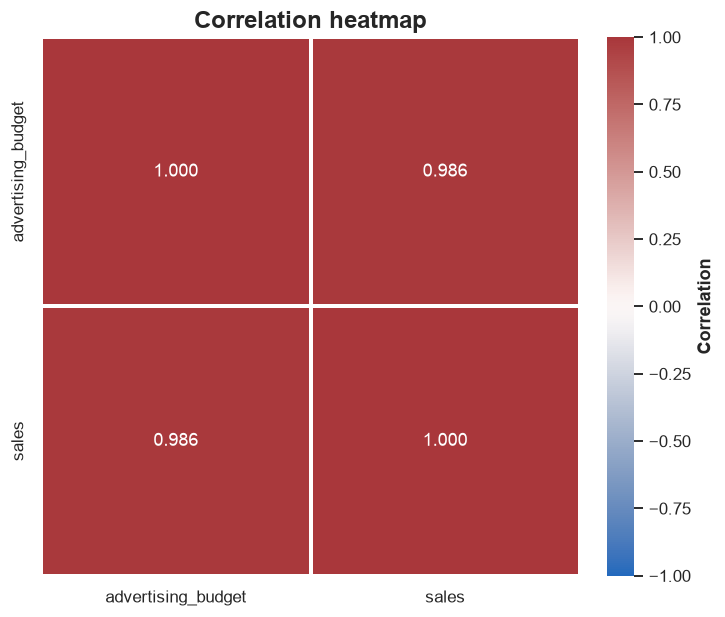

In [13]:
correlation = df[["advertising_budget", "sales"]].corr()
fig, ax = plt.subplots(figsize=(6.5, 5.5))
sns.heatmap(
    correlation,
    annot=True,
    fmt=".3f",
    cmap="vlag",
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=1.5,
    cbar_kws={"label": "Correlation"},
    ax=ax,
)
ax.set_title("Correlation heatmap", fontsize=16)
display(fig)
plt.close(fig)

### Reading the correlation heatmap

The value 0.986 indicates a very strong positive linear association between advertising budget and sales in these observations. Correlation measures association, not causation.

## Leverage and influence

Leverage identifies observations with unusual predictor values. Cook's distance combines leverage and residual size to flag observations that could strongly affect the fitted line. These are diagnostic signals, not automatic reasons to remove data.

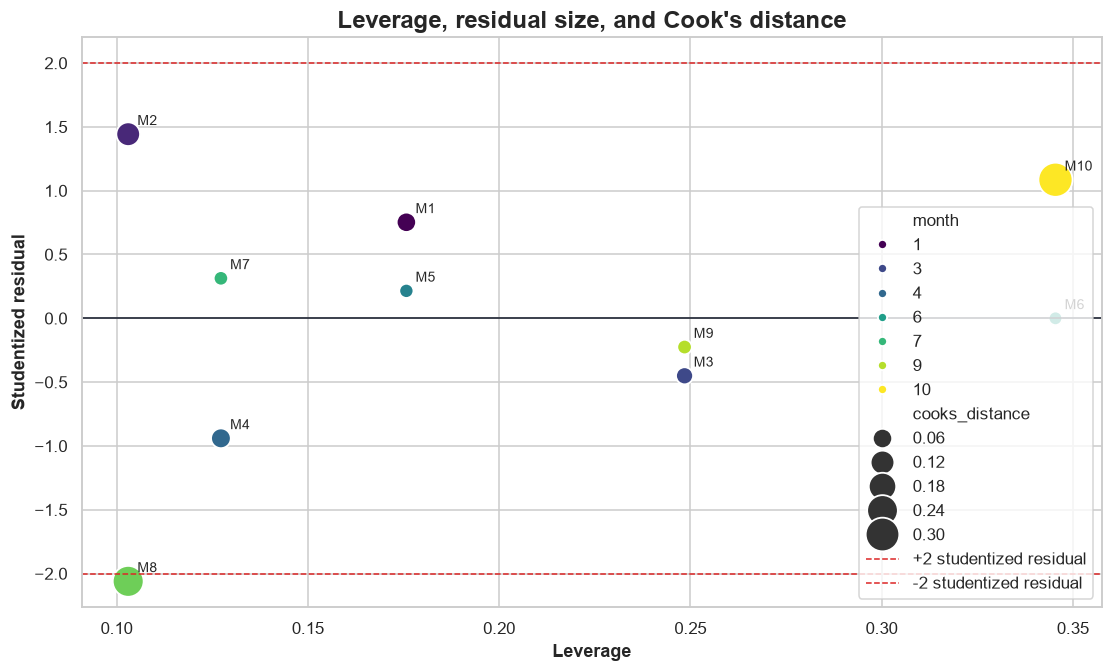

In [14]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(
    data=diagnostics,
    x="leverage",
    y="studentized_residual",
    hue="month",
    size="cooks_distance",
    sizes=(80, 500),
    palette="viridis",
    edgecolor="white",
    linewidth=1.2,
    ax=ax,
)
for _, row in diagnostics.iterrows():
    ax.annotate(
        f"M{int(row['month'])}",
        (row["leverage"], row["studentized_residual"]),
        xytext=(6, 6),
        textcoords="offset points",
        fontsize=9,
    )
ax.axhline(0, color="#111827", linewidth=1)
ax.axhline(
    2, color="#dc2626", linestyle="--", linewidth=1, label="+2 studentized residual"
)
ax.axhline(
    -2, color="#dc2626", linestyle="--", linewidth=1, label="-2 studentized residual"
)
ax.set_title("Leverage, residual size, and Cook's distance", fontsize=16)
ax.set_xlabel("Leverage")
ax.set_ylabel("Studentized residual")
ax.legend(loc="best", frameon=True)
display(fig)
plt.close(fig)

### Reading the leverage plot

Points farther right have more unusual budget values; larger bubbles have greater Cook’s distance and influence. Month 10 has the largest Cook’s distance, while month 8 is just beyond the −2 residual guide, so both deserve attention.

## R-squared and final evaluation

Calculate the coefficient of determination from the residual and total sums of squares:

- `SSE = sum((y_i - y_hat_i) ** 2)`
- `SST = sum((y_i - y_mean) ** 2)`
- `R^2 = 1 - SSE / SST`

In [15]:
sse = np.sum((y - ols_results.fittedvalues) ** 2)
sst = np.sum((y - y_mean) ** 2)
r_squared = 1 - sse / sst

metrics = pd.DataFrame(
    {
        "metric": ["SSE", "SST", "R-squared", "Explained variation"],
        "value": [sse, sst, r_squared, r_squared * 100],
        "units": ["(thousand units)^2", "(thousand units)^2", "proportion", "percent"],
    }
)
display(metrics)
print(f"R-squared = {r_squared:.6f}")
print(f"Approximately {r_squared * 100:.2f}% of sample sales variation is explained.")

assert np.isclose(sse, 3.7333333333)
assert np.isclose(sst, 136.1)
assert np.isclose(r_squared, 0.9725691893)

,metric,value,units
0,SSE,3.7333,(thousand units)^2
1,SST,136.1000,(thousand units)^2
2,R-squared,0.9726,proportion
3,Explained variation,97.2569,percent


R-squared = 0.972569
Approximately 97.26% of sample sales variation is explained.


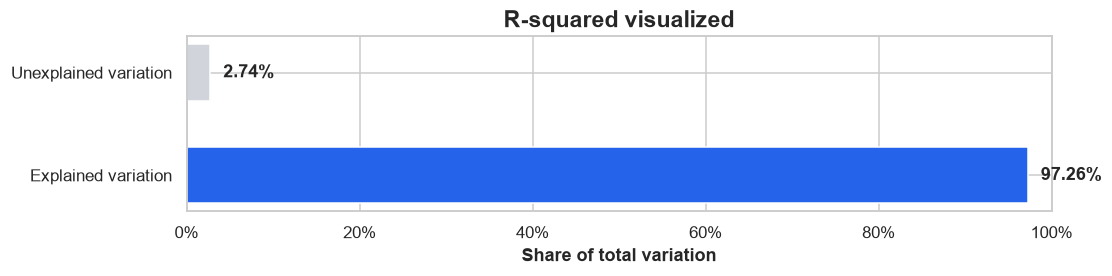

In [16]:
fig, ax = plt.subplots(figsize=(10, 2.4))
ax.barh(
    ["Explained variation", "Unexplained variation"],
    [r_squared, 1 - r_squared],
    color=["#2563eb", "#d1d5db"],
    edgecolor="white",
    height=0.55,
)
ax.set_xlim(0, 1)
ax.set_xlabel("Share of total variation")
ax.set_title("R-squared visualized", fontsize=15)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda value, _: f"{value:.0%}"))
for index, value in enumerate([r_squared, 1 - r_squared]):
    ax.text(value + 0.015, index, f"{value:.2%}", va="center", fontweight="bold")
display(fig)
plt.close(fig)

### Reading the R-squared plot

The chart shows that 97.26% of sample sales variation is explained by the fitted line, leaving 2.74% unexplained. This describes fit for these data; it does not prove causation or guarantee future accuracy.

## Final answers

- **Fitted equation:** `Sales_hat = 1.7333 + 1.2667 * Advertising Budget`.
- **Intercept:** `1.7333` thousand units sold at a zero advertising budget. Zero is outside the observed range.
- **Slope:** `1.2667` thousand additional units sold per additional thousand dollars of advertising budget. This is an association in the sample, not proof of causation.
- **Prediction at USD 12,000:** `16.9333` thousand units, approximately `16,933` units. This is extrapolation beyond the observed maximum budget of USD 10,000.
- **R-squared:** `0.972569`, so approximately `97.26%` of the observed sales variation is explained by the fitted linear relationship.

A high R-squared does not establish causation, guarantee future accuracy, or replace residual and influence diagnostics.